# Mapping from `datascience` to Polars

Welcome! This notebook is an unofficial resource created by the Data Science division.

It serves as an introduction to working with Python's `Polars` library for students who have taken data 8. The functions introduced will be analogous to those in Berkeley's `datascience` module, with examples provided for each.

We will cover the following topics in this notebook:
1. [Basics of Polars](#basics)
    - [Importing and Loading Packages](#import)
<br>
<br>
2. [Dataframes: Working with Tabular Data](#dataframes)
    - [Creating a Dataframe](#creating)
    - [Accessing Values in Dataframe](#accessing)
    - [Manipulating Data](#manipulating)
<br>
<br>
3. [Visualizing Data](#visualizing)
    - [Histograms](#histograms)
    - [Line Plots](#line)
    - [Scatter Plots](#scatter)
    - [Bar Plots](#bar)

## 1. Basics {#basics}

This notebook assumes familiarity with Python concepts, syntax and data structures at the level of Data 8. For a brief refresher on some Python concepts, refer to this [Python Basics Guide on Github](https://github.com/TiesdeKok/LearnPythonforResearch/blob/master/0_python_basics.ipynb)

Python has a great ecosystem of data-centric packages which makes it excellent for data analysis. `Polars` is one of those packages, and makes importing and analyzing data much easier. It gives us a single, convenient place to do most of our data analysis work, and it hands the results off to packages like `NumPy` and matplotlib when we want to compute on them or draw them.

### 1.1 Importing and Loading Packages {#import}

It is useful to import certain packages in our workspace for analysis and data visualization. But first, we may need to install these package if they are not present already. We do this via the command line as follows:

In [ ]:
# run this cell to install packages
%%capture
!pip install datascience
!pip install polars
!pip install numpy

Once we have installed the required packages, we do not need to reinstall them again when we start or reopen a Jupyter notebook. We can simply import them using the `import` keyword. Since we import `Polars` as `pl`, we need to prefix all functions with `pl`, similar to how we prefix all numpy functions with `np` (such as `np.append()`).

In [ ]:
# run this cell to import the following packages
from datascience import * # import the datascience package
import polars as pl # import the polars library. pl is a common shorthand for polars
import numpy as np # import numpy for working with numbers

## 2. Dataframes: Working with Tabular Data {#dataframes}

In Python's `datascience` module, we used `Table` to build our dataframes and used commands such as `select()`, `where()`, `group()`, `column()` etc. In this section, we will go over some basic commands to work with tabular data in `Polars`

### 2.1 Creating a Dataframe {#creating}

`Polars` introduces a data structure (i.e. dataframe) that represents data as a table with columns and rows.

In Python's `datascience` module that is used in Data 8, this is how we created tables from scratch by extending an empty table:

In [102]:
t = Table().with_columns([
     'letter', ['a', 'b', 'c', 'z'],
     'count',  [  9,   3,   3,   1],
     'points', [  1,   2,   2,  10],
 ])
t

letter,count,points
a,9,1
b,3,2
c,3,2
z,1,10


In `Polars`, we can use `pl.DataFrame` to initialize a dataframe from a dictionary or a list-like object. Refer to the [documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/index.html) for more information

In [ ]:
# example: creating a dataframe from a dictionary
df_from_dict = pl.DataFrame({ 'letter' : ['a', 'b', 'c', 'z'],
                      'count' : [  9,   3,   3,   1],
                      'points' : [  1,   2,   2,  10]
                      })
df_from_dict

More often, we will need to create a dataframe by importing data from a .csv file. In `datascience`, this is how we read data from a csv:

In [104]:
datascience_baby = Table.read_table('data/baby.csv')
datascience_baby

Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
1,120,284,27,62,100,False
2,113,282,33,64,135,False
3,128,279,28,64,115,True
4,108,282,23,67,125,True
5,136,286,25,62,93,False
6,138,244,33,62,178,False
7,132,245,23,65,140,False
8,120,289,25,62,125,False
9,143,299,30,66,136,True
10,140,351,27,68,120,False


In `Polars`, we use `pl.read_csv()` to read data from a csv file. Sometimes, depending on the data file, we may need to specify the parameters `separator`, `has_header`, `encoding` or `eol_char` as well. For a full list of parameters, refer to [this guide](https://docs.pola.rs/api/python/stable/reference/api/polars.read_csv.html)

In [ ]:
# reading baby.csv (located in current working directory)
baby = pl.read_csv('data/baby.csv')
baby.head() # display first few rows of dataframe

In [106]:
# view summary of data
baby.describe()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight
count,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000
mean,587.500000,119.462521,279.101363,27.228279,64.049404,128.478705
std,339.048915,18.328671,16.010305,5.817839,2.526102,20.734282
min,1.000000,55.000000,148.000000,15.000000,53.000000,87.000000
25%,294.250000,108.000000,272.000000,23.000000,62.000000,114.250000
50%,587.500000,120.000000,280.000000,26.000000,64.000000,125.000000
75%,880.750000,131.000000,288.000000,31.000000,66.000000,139.000000
max,1174.000000,176.000000,353.000000,45.000000,72.000000,250.000000


In [ ]:
# example: loading csv from URL
# this file ends its rows with a carriage return, so we say so with eol_char
sat = pl.read_csv('https://raw.githubusercontent.com/data-8/materials-sp18/master/lec/sat2014.csv', eol_char='\r')
sat.head()

In [ ]:
# view information about dataframe
print(sat.shape) # view dimensions (rows, cols)
print(sat.columns) # view column names

### 2.2 Accessing Values in Dataframe {#accessing}

In `datascience`, we can use `column()` to access values in a particular column as follows:

In [109]:
# access column 'letter'. returns array
t.column('letter')

array(['a', 'b', 'c', 'z'],
      dtype='<U1')

In `Polars`, columns are also known as Series. We can access a `Polars` series by using the square bracket notation.

In [110]:
# returns Series object
sat['State']

0             North Dakota
1                 Illinois
2                     Iowa
3             South Dakota
4                Minnesota
5                 Michigan
6                Wisconsin
7                 Missouri
8                  Wyoming
9                   Kansas
10                Kentucky
11                Nebraska
12                Colorado
13             Mississippi
14               Tennessee
15                Arkansas
16                Oklahoma
17                    Utah
18               Louisiana
19                    Ohio
20                 Montana
21                 Alabama
22              New Mexico
23           New Hampshire
24           Massachusetts
25                 Vermont
26                 Arizona
27                  Oregon
28                Virginia
29              New Jersey
30             Connecticut
31           West Virginia
32              Washington
33              California
34                  Alaska
35          North Carolina
36            Pennsylvania
3

If we want a numpy array of column values, we can call the method `to_numpy()` on a Series object:

In [ ]:
sat['State'].to_numpy()

In `datascience`, we used `take()` to access a row in the Table:

In [112]:
# selecting first two rows using Python's slicing notation
t.take[0:2]

letter,count,points
a,9,1
b,3,2


In `Polars`, we address rows and columns by their position inside a single pair of square brackets, with the syntax `df[<rows>, <columns>]`. For more information on indexing, refer to [this guide](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.__getitem__.html)

In [ ]:
# selecting first two rows using slicing notation
baby[0:2, :]

In [ ]:
# specifying row indices
baby[[1, 4, 6], :]

We can also access a specific value in the dataframe by passing in the row and column indices:

In [ ]:
# get value in second row, third column
baby[1, 2]

### 2.3 Manipulating Data {#manipulating}

**Adding Columns**

Adding a new column in `datascience` is done by the `with_column()` function as follows:

In [116]:
t.with_column('vowel', ['yes', 'no', 'no', 'no'])
t

letter,count,points
a,9,1
b,3,2
c,3,2
z,1,10


In `Polars`, we use `with_columns()` and hand it a `pl.Series` carrying the name and the values:

In [ ]:
# adding a new column
df_from_dict = df_from_dict.with_columns(pl.Series('newcol', [5, 6, 7, 8]))
df_from_dict

We can also add an existing column to the new dataframe as a new column by performing an operation on it. `pl.col()` names the column we are computing from, and `alias()` names the column we are creating:

In [ ]:
# adding count * 2 to the dataframe
df_from_dict = df_from_dict.with_columns((pl.col('count') * 2).alias('doublecount'))
df_from_dict

**Selecting Columns**

In `datascience`, we used `select()` to subset the dataframe by selecting columns:

In [119]:
t.select(['letter', 'points'])

letter,points
a,1
b,2
c,2
z,10


`Polars` uses `select()` for the same job, and gives us back a dataframe. A single column pulled out with the single bracket notation comes back as a Series

In [ ]:
# select returns a new dataframe
df_from_dict.select(['count', 'doublecount'])

**Filtering Rows Conditionally**

In `datascience`, we used `where()` to select rows according to a given condition:

In [121]:
t.where('points', 2) # rows where points == 2

letter,count,points
b,3,2
c,3,2


In [122]:
t.where(t['count'] < 8) # rows where count < 8

letter,count,points
b,3,2
c,3,2
z,1,10


In `Polars`, we use `filter()` to keep the rows where a condition holds. We write the condition with `pl.col()`, which refers to a column of whatever dataframe the expression is evaluated against:

In [ ]:
# series of booleans
baby['Maternal.Smoker'] == True

In [ ]:
# filter rows by condition Maternal.Smoker == True
baby.filter(pl.col('Maternal.Smoker') == True)

In [ ]:
# filtering with multiple conditions
df_from_dict.filter((pl.col('count') < 8) & (pl.col('points') > 5))

**Renaming Columns**

In `datascience`, we used `relabeled()` to rename columns:

In [126]:
# rename 'points' to 'other name'
t.relabeled('points', 'other name')

letter,count,other name
a,9,1
b,3,2
c,3,2
z,1,10


`Polars` uses `rename()`, which takes a dictionary mapping each name to be replaced to its replacement:

In [ ]:
# rename 'points' to 'other name'
df_from_dict.rename({"points" : "other name"})

**Sorting Dataframe by Column**

In `datascience` we used `sort()` to sort a Table according to the values in a column:

In [128]:
# sort by count
t.sort('count')

letter,count,points
z,1,10
b,3,2
c,3,2
a,9,1


In `Polars`, we use `sort()` to sort by column. The first argument names the column we want to sort by, and the optional parameter `descending = True` puts the largest values first:

In [ ]:
# sort by count, descending
df_from_dict.sort('count', descending = True)

**Grouping and Aggregating**

In `datascience`, we used `group()` and the `collect` argument to group a Table by a column and aggregrate values in another column:

In [130]:
# group by count and aggregate by sum
t.select(['count', 'points']).group('count', collect=sum)

count,points sum
1,10
3,4
9,1


In `Polars`, we use `group_by()` to group the dataframe and `agg()` to say how the values in each group should be combined. The column we grouped on comes back as an ordinary column of the result. Passing `maintain_order=True` returns the groups in the order their keys first appear. For more information, refer to the [documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.group_by.html)

In [ ]:
# selecting two columns for brevity
df_subset = df_from_dict.select(['count', 'points'])
df_subset

In [ ]:
count_sums_df = df_subset.group_by('count', maintain_order=True).agg(pl.col('points').sum())
count_sums_df

**Pivot Tables**

In `datascience`, we used the `pivot()` function to build contingency tables:

In [133]:
# creating new Table
cones_tbl = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate', 'bubblegum'),
    'Color', make_array('pink', 'light brown', 'dark brown', 'pink', 'dark brown', 'pink'),
    'Price', make_array(3.55, 4.75, 5.25, 5.25, 5.25, 4.75)
)

cones_tbl

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [134]:
# pivoting on color and flavor
cones_tbl.pivot("Flavor", "Color")

Color,bubblegum,chocolate,strawberry
dark brown,0,2,0
light brown,0,1,0
pink,1,0,2


We can also pass in the parameters `values` to specify the values in the table and `collect` to specify the aggregration function.

In [135]:
# setting parameters values and collect
cones_tbl.pivot("Flavor", "Color", values = "Price", collect = np.sum)

Color,bubblegum,chocolate,strawberry
dark brown,0,10.5,0
light brown,0,4.75,0
pink,4.75,0,8.8


In `Polars`, we use the `pivot()` method to create a contingency table. The argument `on` is similar to the first argument in `datascience`'s `pivot` function and sets the column names of the pivot table. The argument `index` is similar to the second argument in `datascience`'s `pivot` function and sets the first column of the pivot table or the keys to group on. For more information, refer to the [documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.pivot.html)

In [ ]:
# creating new dataframe
cones_df = pl.DataFrame({"Flavor" : ['strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate', 'bubblegum'],
                         "Color" : ['pink', 'light brown', 'dark brown', 'pink', 'dark brown', 'pink'],
                         "Price" : [3.55, 4.75, 5.25, 5.25, 5.25, 4.75]})
cones_df

In [ ]:
# creating the pivot table. values = None counts the rows in each combination
cones_df.pivot(on = "Flavor", index = "Color", values = None, aggregate_function = "len")

A flavor and color combination that never occurs is counted as `0`.

We can also specify the parameters `values` (equivalent to `values` in `datascience`'s `pivot`) and `aggregate_function` (equivalent to `collect` in `datascience`'s `pivot`)

In [ ]:
# additional arguments
cones_df.pivot(on = "Flavor", index = "Color", values = "Price", aggregate_function = "sum")

**Joining/Merging**

In `datascience`, we used `join()` to join two tables based on shared values in columns. We specify the column name in the first table to match on, the name of the second table and the column name in the second table to match on.

In [139]:
# creating new table
ratings_tbl = Table().with_columns(
    'Kind', make_array('strawberry', 'chocolate', 'vanilla'),
    'Stars', make_array(2.5, 3.5, 4)
)
ratings_tbl

Kind,Stars
strawberry,2.5
chocolate,3.5
vanilla,4


In [140]:
# joining cones and ratings
cones_tbl.join("Flavor", ratings_tbl, "Kind")

Flavor,Color,Price,Stars
chocolate,light brown,4.75,3.5
chocolate,dark brown,5.25,3.5
chocolate,dark brown,5.25,3.5
strawberry,pink,3.55,2.5
strawberry,pink,5.25,2.5


In `Polars`, we can use the `join()` method to join two tables together. The first parameter is the second table to join on. The parameters `left_on` and `right_on` specify the columns to use in the left and right tables respectively, and the matched column keeps the name it had in the left table. There are more parameters such as `how` which specify what kind of join to perform (Inner (Default), Outer, Left, Right, Semi, Anti). For more information, refer to the [documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html)

In [ ]:
# creating new ratings df
ratings_df = pl.DataFrame({"Kind" : ['strawberry', 'chocolate', 'vanilla'],
                           "Stars" : [2.5, 3.5, 4.0]})
ratings_df

In [ ]:
# joining cones and ratings
cones_df.join(ratings_df, left_on = "Flavor", right_on = "Kind")

## 3. Visualizing Data {#visualizing}

In `datascience`, we learned to plot data using histograms, line plots, scatter plots and histograms. The corresponding functions were `hist()`, `plot()`, `scatter()` and `barh()`. `Polars` leaves the drawing to matplotlib: we pull the columns we want out of the dataframe with `to_numpy()` and hand the arrays to a matplotlib function. We write the axis labels ourselves.

In this section we will go through examples of such plots in `Polars`

### 3.1 Histograms {#histograms}

In `datascience`, we used `hist()` to create a histogram. In this example, we will be using data from `baby.csv`. Recall that the baby data set contains data on a random sample of 1,174 mothers and their newborn babies. The column `Birth.Weight` contains the birth weight of the baby, in ounces; `Gestational.Days` is the number of gestational days, that is, the number of days the baby was in the womb. There is also data on maternal age, maternal height, maternal pregnancy weight, and whether or not the mother was a smoker.

In [ ]:
# importing matplotlib for plotting
import matplotlib.pyplot as plt
%matplotlib inline

In [144]:
# reading in the data
datascience_baby = Table.read_table('data/baby.csv')
datascience_baby

Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
1,120,284,27,62,100,False
2,113,282,33,64,135,False
3,128,279,28,64,115,True
4,108,282,23,67,125,True
5,136,286,25,62,93,False
6,138,244,33,62,178,False
7,132,245,23,65,140,False
8,120,289,25,62,125,False
9,143,299,30,66,136,True
10,140,351,27,68,120,False


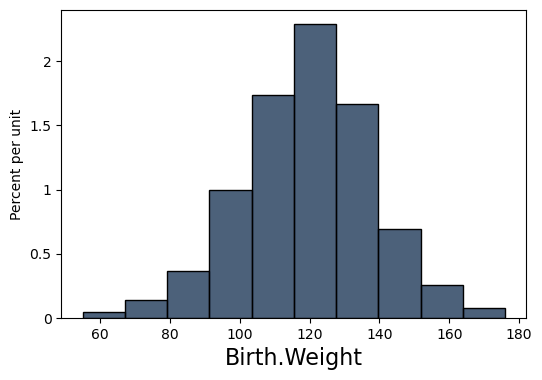

In [145]:
# creating a histogram
datascience_baby.hist('Birth.Weight')

With `Polars`, we use `plt.hist()` to create histograms. Refer to the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) for a full list of parameters

In [ ]:
# creating a histogram
plt.hist(baby['Birth.Weight'].to_numpy(), bins=20)
plt.xlabel('Birth.Weight')
plt.ylabel('Count');

### 3.2 Line Plots {#line}

In `datascience`, we used `plot()` to create a line plot of numerical values. In this example, we will be using census data and plot variables such as Age in a line plot

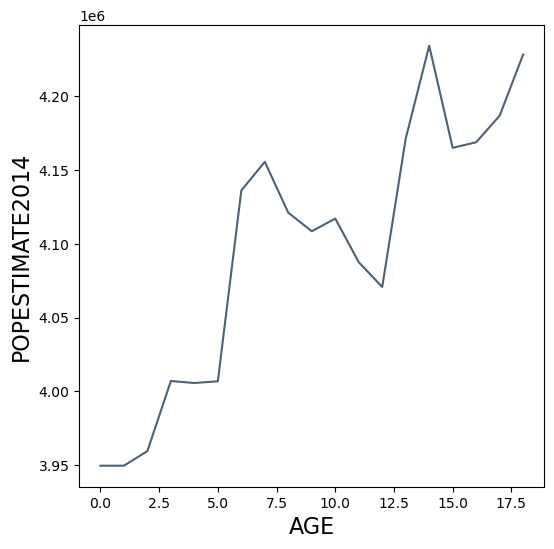

In [147]:
# line plot in datascience
census_tbl = Table.read_table("https://raw.githubusercontent.com/data-8/materials-x18/master/lec/x18/1/census.csv").select(['SEX', 'AGE', 'POPESTIMATE2014'])
children_tbl = census_tbl.where('SEX', are.equal_to(0)).where('AGE', are.below(19)).drop('SEX')
children_tbl.plot('AGE')

With `Polars`, we filter down to the rows we want and then pass the two columns to `plt.plot()`. For a full list of parameters, refer to the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

In [ ]:
# Polars
census_df = pl.read_csv("https://raw.githubusercontent.com/data-8/materials-x18/master/lec/x18/1/census.csv").select(["SEX", "AGE", "POPESTIMATE2014"])
children_df = census_df.filter((pl.col("SEX") == 0) & (pl.col("AGE") < 19)).drop("SEX")
plt.plot(children_df["AGE"].to_numpy(), children_df["POPESTIMATE2014"].to_numpy())
plt.xlabel("AGE")
plt.ylabel("POPESTIMATE2014");

### 3.3 Scatter plots {#scatter}

In `datascience`, we used `scatter()` to create a scatter plot of two numerical columns

In [149]:
football_tbl = Table.read_table('https://raw.githubusercontent.com/data-8/materials-sp18/master/lec/deflategate.csv')
football_tbl

Team,Blakeman,Prioleau
Patriots,11.5,11.8
Patriots,10.85,11.2
Patriots,11.15,11.5
Patriots,10.7,11
Patriots,11.1,11.45
Patriots,11.6,11.95
Patriots,11.85,12.3
Patriots,11.1,11.55
Patriots,10.95,11.35
Patriots,10.5,10.9


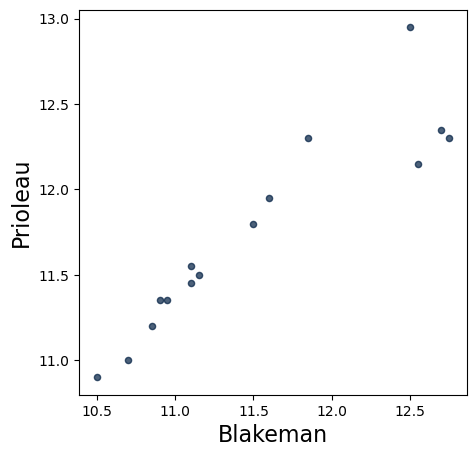

In [150]:
football_tbl.scatter('Blakeman', 'Prioleau')

With `Polars`, we use `plt.scatter()` to create a scatter plot. For a full list of parameters, refer to the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)

In [ ]:
football_df = pl.read_csv('https://raw.githubusercontent.com/data-8/materials-sp18/master/lec/deflategate.csv')
plt.scatter(football_df["Blakeman"].to_numpy(), football_df["Prioleau"].to_numpy())
plt.xlabel("Blakeman")
plt.ylabel("Prioleau");

### 3.4 Bar Plots {#bar}

In `datascience`, we used `barh()` to create a horizontal bar plot

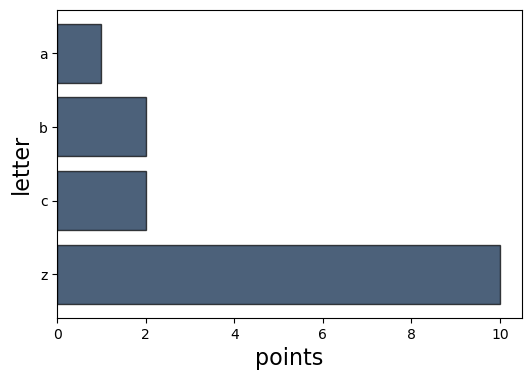

In [152]:
t.barh("letter", "points")

With `Polars`, we use `plt.barh()` to create a horizontal bar chart. The first argument holds the category labels and the second holds the bar lengths. For a full list of parameters, refer to the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html)

In [ ]:
plt.barh(df_from_dict['letter'].to_numpy(), df_from_dict['points'].to_numpy())
plt.xlabel("points")
plt.ylabel("letter");

---

## Further Reading

Here is a list of useful `Polars` resources:

- [Polars Documentation](https://docs.pola.rs/api/python/stable/reference/index.html)
- [Polars User Guide](https://docs.pola.rs/user-guide/getting-started/)
- [Polars Expressions Guide](https://docs.pola.rs/user-guide/expressions/)